# Heart Disease Prediction Using Decision Tree Classification 

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score 
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score 
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import pickle

### Step 2 Import Dataset

In [5]:
df=pd.read_csv("Heart_Disease_Prediction.csv")

In [6]:
df.head()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      270 non-null    int64  
 1   Sex                      270 non-null    int64  
 2   Chest pain type          270 non-null    int64  
 3   BP                       270 non-null    int64  
 4   Cholesterol              270 non-null    int64  
 5   FBS over 120             270 non-null    int64  
 6   EKG results              270 non-null    int64  
 7   Max HR                   270 non-null    int64  
 8   Exercise angina          270 non-null    int64  
 9   ST depression            270 non-null    float64
 10  Slope of ST              270 non-null    int64  
 11  Number of vessels fluro  270 non-null    int64  
 12  Thallium                 270 non-null    int64  
 13  Heart Disease            270 non-null    object 
dtypes: float64(1), int64(12), 

In [8]:
df.shape

(270, 14)

In [9]:
df.describe()

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


### Step 3 EDA


In [10]:
df.isnull().sum() #Missing value

Age                        0
Sex                        0
Chest pain type            0
BP                         0
Cholesterol                0
FBS over 120               0
EKG results                0
Max HR                     0
Exercise angina            0
ST depression              0
Slope of ST                0
Number of vessels fluro    0
Thallium                   0
Heart Disease              0
dtype: int64

In [11]:
df.duplicated().sum() #Duplicate values

np.int64(0)

In [12]:
df.drop_duplicates(inplace=True) #Remove Duplicate

In [13]:
#encode target value
encoder = LabelEncoder()
df["Heart Disease"] = encoder.fit_transform(df["Heart Disease"])

In [14]:
df.head() #check data after encoding 

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,1
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,0
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,1
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,0
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,0


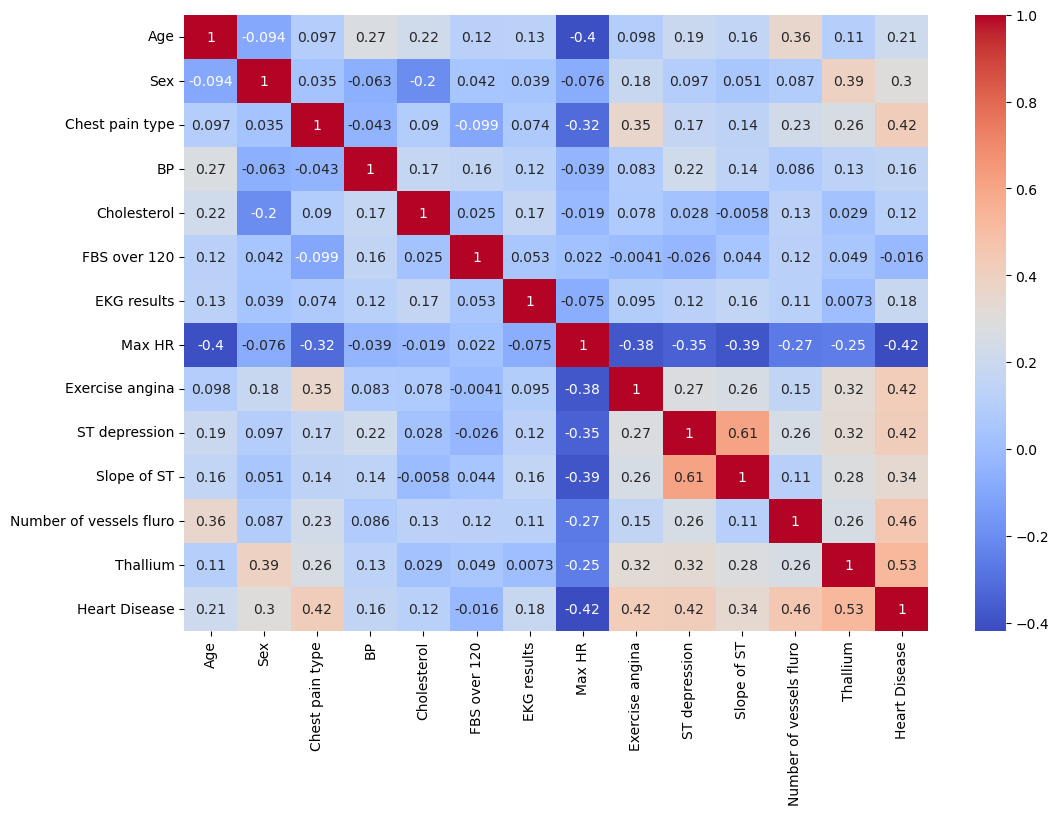

In [15]:
#correlation Heatmap
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(),annot=True,cmap="coolwarm")

plt.show()

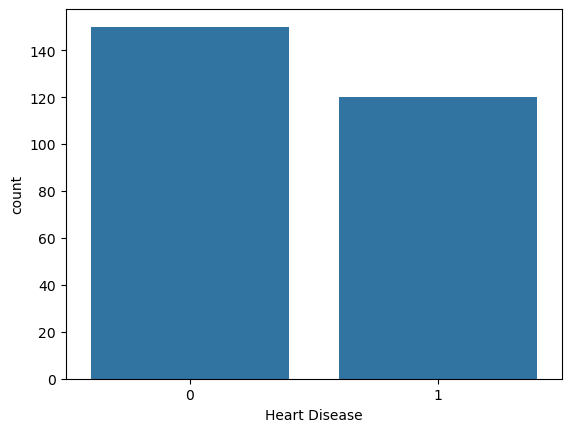

In [16]:
#count Plot
sns.countplot(x="Heart Disease",data=df)

plt.show()

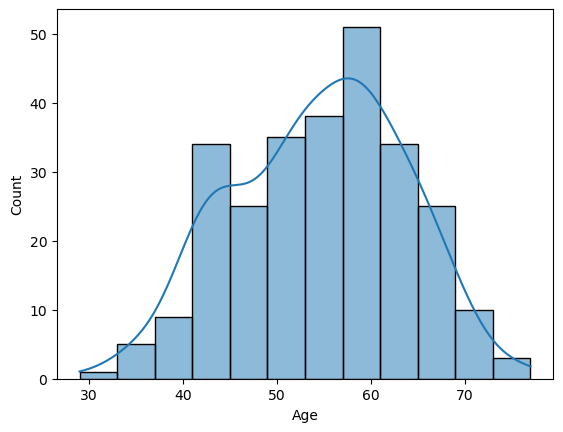

In [17]:
#age distribution
sns.histplot(df["Age"],kde=True)

plt.show()

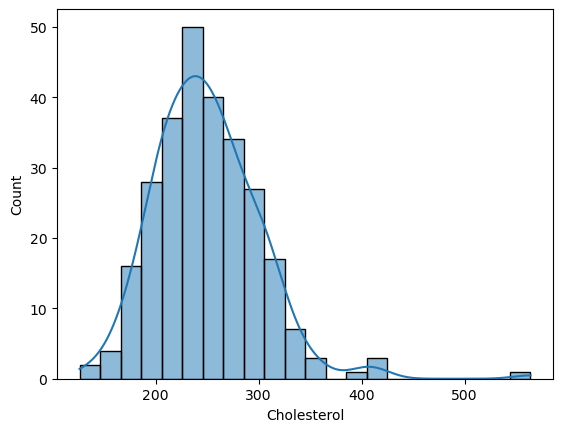

In [18]:
# cholesterol Distribution
sns.histplot(df["Cholesterol"],kde=True)

plt.show()


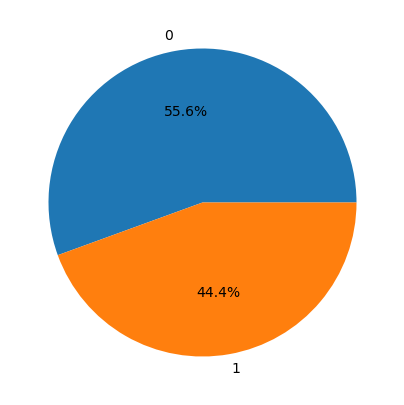

In [19]:
plt.figure(figsize=(5,5))

df["Heart Disease"].value_counts().plot(kind="pie",autopct="%1.1f%%")

plt.ylabel("")

plt.show()

### step 4 Target Variable Selection 

In [20]:
X = df.drop("Heart Disease",axis=1)

y = df["Heart Disease"]

### Step 5 Train Test Split

In [21]:
X_train,X_test,y_train,y_test = train_test_split(

X,

y,

test_size=0.20,

random_state=42,

stratify=y
)

### Step 6 Import Model

In [22]:
model = DecisionTreeClassifier(

criterion="gini",

max_depth=5,

random_state=42
)

### Step 7 Train Model

In [23]:
model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


### Step 8 Prediction 

In [24]:
y_pred = model.predict(X_test)

### Step 9 Evaluation 

In [25]:
print("Accuracy :",accuracy_score(y_test,y_pred))

Accuracy : 0.7962962962962963


In [26]:
print("Precision :",precision_score(y_test,y_pred)) # precision

Precision : 0.7407407407407407


In [27]:
print("Recall :",recall_score(y_test,y_pred)) # recall

Recall : 0.8333333333333334


In [28]:
print("F1 Score :",f1_score(y_test,y_pred)) #F1 score 

F1 Score : 0.7843137254901961


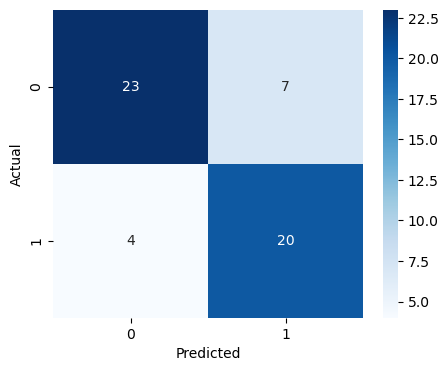

In [29]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()                        #CONFUSION MATRIX

In [30]:
print(classification_report(y_test,y_pred)) #classification report

              precision    recall  f1-score   support

           0       0.85      0.77      0.81        30
           1       0.74      0.83      0.78        24

    accuracy                           0.80        54
   macro avg       0.80      0.80      0.80        54
weighted avg       0.80      0.80      0.80        54



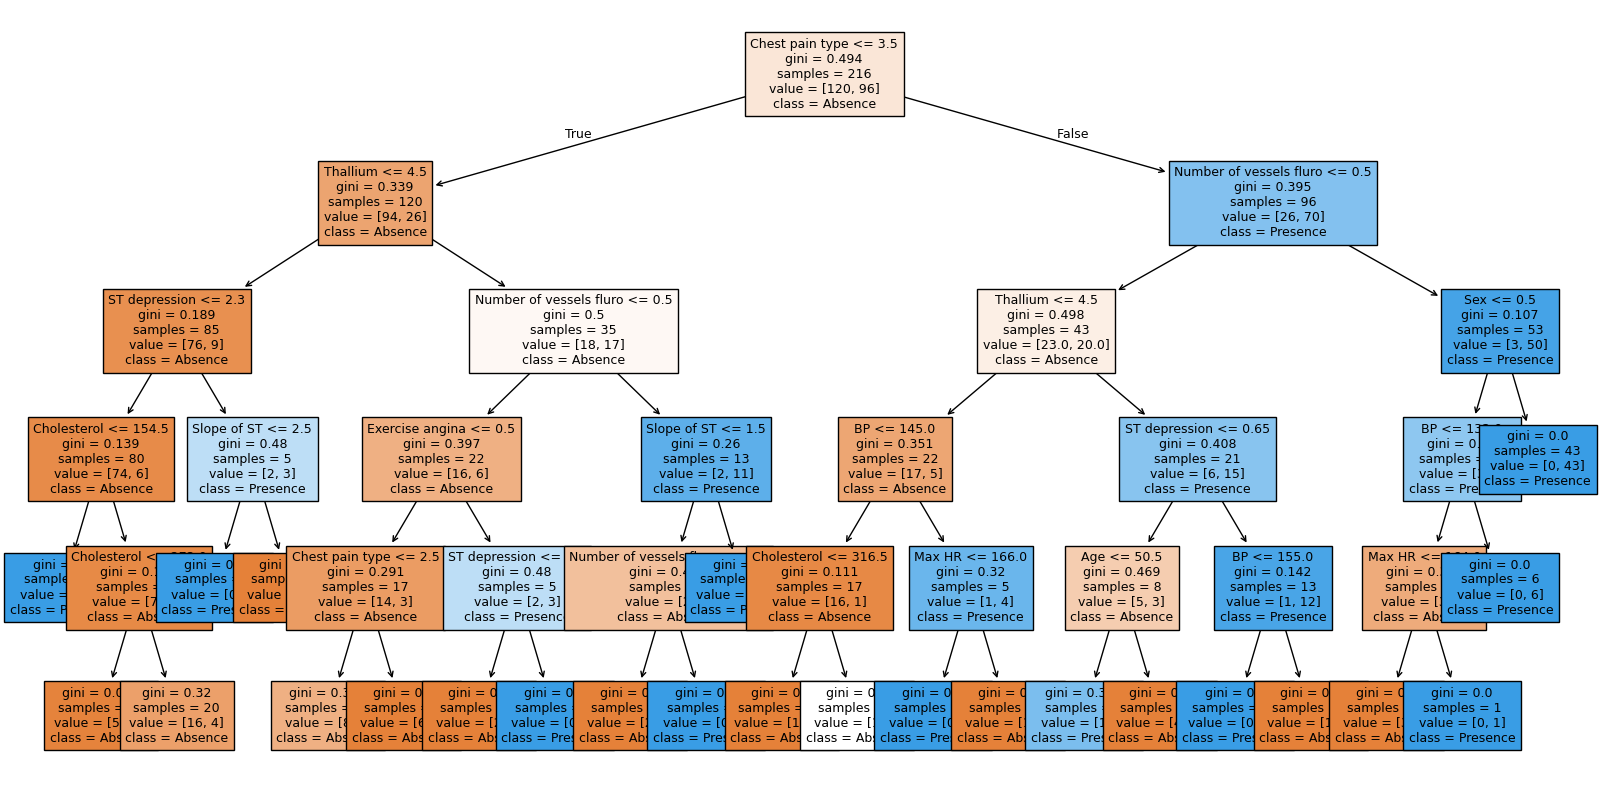

In [31]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))

plot_tree(

model,

feature_names=X.columns,

class_names=["Absence","Presence"],

filled=True,

fontsize=9

)

plt.show()

### Step 10 Convert model into pkl

In [32]:

artifacts = {

    "model":model,

    "encoder":encoder

}

pickle.dump(

artifacts,

open("artifacts.pkl","wb")
)
print("pkl saved successfully")

pkl saved successfully
